## Notebook 3B — Diagnostics & Model Evaluation

### 1. Data Loading

#### Importing libraries

In [124]:
import pandas as pd
import numpy as np

from sklearn.pipeline import (Pipeline)
from sklearn.preprocessing import (StandardScaler)
from sklearn.model_selection import (train_test_split, learning_curve, validation_curve, cross_val_predict)
from sklearn.linear_model import (LassoCV, Lasso)
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
%matplotlib inline

#### Importing Synthetic Data

In [5]:
df = pd.read_csv('Synthetic_Market_Dataframe.csv').drop('Unnamed: 0', axis = 1)

df.head()

,google_spend,meta_spend,tiktok_spend,linkedin_spend,email_spend,ctr,cpc,impressions,revenue,total_spend,google_share,meta_share
0,19352.465824,12112.247848,7472.816369,7495.053656,3676.991724,0.016466,5.286084,85720,313151.792321,50109.575421,0.386203,0.241715
1,47585.001014,14466.351952,6658.241925,11201.201588,1004.108778,0.014253,3.944693,1726885,354471.126119,80914.905256,0.588087,0.178785
2,36867.703149,25709.148099,3523.078250,8440.001710,1798.534502,0.052293,7.733739,4013815,436025.243627,76338.465711,0.482951,0.336778
3,30334.265726,10530.129389,12145.333402,1249.538747,3350.075121,0.077628,2.142338,2142314,252781.463673,57609.342384,0.526551,0.182785
4,8644.913382,26154.665702,9532.483210,2783.703552,2462.237788,0.045190,4.908923,4004822,298776.377299,49578.003634,0.174370,0.527546


### 2. Train/Test/Split

In [7]:
X = df.drop(['revenue', 'total_spend'], axis = 1)
# removing total_spend to prevent data leakage since it is the sum of individual channel spends

y = df['revenue']

### 3. Learning Curves (Data Sufficiency)

#### Regenerating the tuned_lasso_pipe

**Purpose**

To identify if the model is suffering from **high bias** (_underfitting_) or **high variance** (_overfitting_), and determine if collecting more than 5,000 rows would improve performance.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f'The shape of X_train{X_train.shape} matches the shape of y_train{y_train.shape}, likewise shape of X_test{X_test.shape} matches the shape of y_test{y_test.shape}.')

The shape of X_train(4000, 10) matches the shape of y_train(4000,), likewise shape of X_test(1000, 10) matches the shape of y_test(1000,).


In [19]:
lassocv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(alphas = np.logspace(-3,3,50)))
])

lassocv_pipe.fit(X_train, y_train)

lassocv_alpha = lassocv_pipe.named_steps['model'].alpha_

print(f'The Optimal LassoCV alpha for raw data is {lassocv_alpha}.')

The Optimal LassoCV alpha for raw data is 59.636233165946365.


In [127]:
tuned_lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha = lassocv_alpha))
])

In [40]:
# Calculate the learning curve scores

train_sizes_lc, train_scores_lc, val_scores_lc = learning_curve(
    tuned_lasso_pipe, X, y, cv = 5, scoring = 'r2', 
    train_sizes = np.linspace(0.1, 1.0, 10),
    # creates 10 evenly spaced steps from 10% of data to train to 100% data to train 
    n_jobs = -1
    # -1 tells commands computer to use all available CPU cores to run the cross-validation folds simultaneously
)

# Calculating mean scores across folds

train_lc_mean = np.mean(train_scores_lc, axis = 1)
val_lc_mean = np.mean(val_scores_lc, axis = 1)

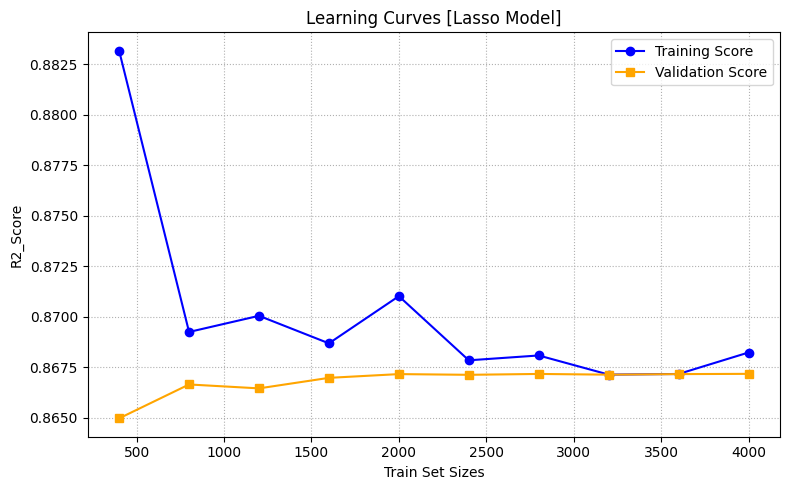

In [42]:
# Plotting learning Curve

plt.figure(figsize = (8,5))

plt.plot(train_sizes_lc, train_lc_mean, color = 'blue', marker = 'o', label = 'Training Score')
plt.plot(train_sizes_lc, val_lc_mean, color = 'orange', marker = 's', label = 'Validation Score')

plt.title('Learning Curves [Lasso Model]')
plt.xlabel('Train Set Sizes')
plt.ylabel('R2_Score')
plt.legend()
plt.grid(True, linestyle = ':')
plt.tight_layout()
plt.show();

**Key Takeaway**

The validation curve has completely flattened out at a reasonably high score, meaning more data will not improve performance; the linear architecture has maxed out its learning capacity.

### 4. Validation Curves (Hyperparameter Tuning)

**Purpose**

While the learning_curve checks if the model needs more data, the validation_curve checks how model responds to changes in its hyperparameters.

In [52]:
# Preparing an unfitted lasso pipe

base_lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter = 50000))
])

# Defining the range of alphas to test on raw dataset
# Generates 50 numbers spaced evenly on a logarithmic scale from 0.001 to 1000.
params_range = np.logspace(-3,3,20)

# Compute validation curve data

train_scores_vc, val_scores_vc = validation_curve(
    base_lasso_pipe, X, y, cv = 5, scoring = 'r2', n_jobs = -1,
    param_range = params_range,
    param_name = 'model__alpha'
    #  informs Scikit-Learn to look inside the component 'model' and vary its parameter 'alpha'.
)

# Calculating mean scores across folds

train_vc_mean = np.mean(train_scores_vc, axis = 1)
val_vc_mean = np.mean(val_scores_vc, axis = 1)

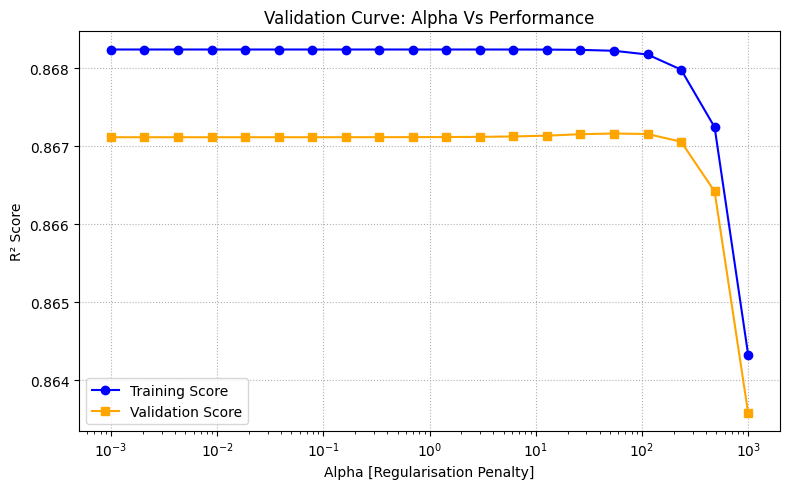

In [58]:
# Plot parameter vs Score

plt.figure(figsize = (8,5))

plt.xscale('log')

plt.plot(params_range, train_vc_mean, color = 'blue', marker = 'o', label = 'Training Score')
plt.plot(params_range, val_vc_mean, color = 'orange', marker = 's', label = 'Validation Score')

plt.title('Validation Curve: Alpha Vs Performance')
plt.xlabel('Alpha [Regularisation Penalty]')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, linestyle = ':')
plt.tight_layout()
plt.show();

### 5. Residual Analysis (Error Distribution)

In [63]:
# Generate out-of-fold predictions using cross-validation

cv_predict = cross_val_predict(tuned_lasso_pipe, X, y, cv = 5)

residuals = y - cv_predict

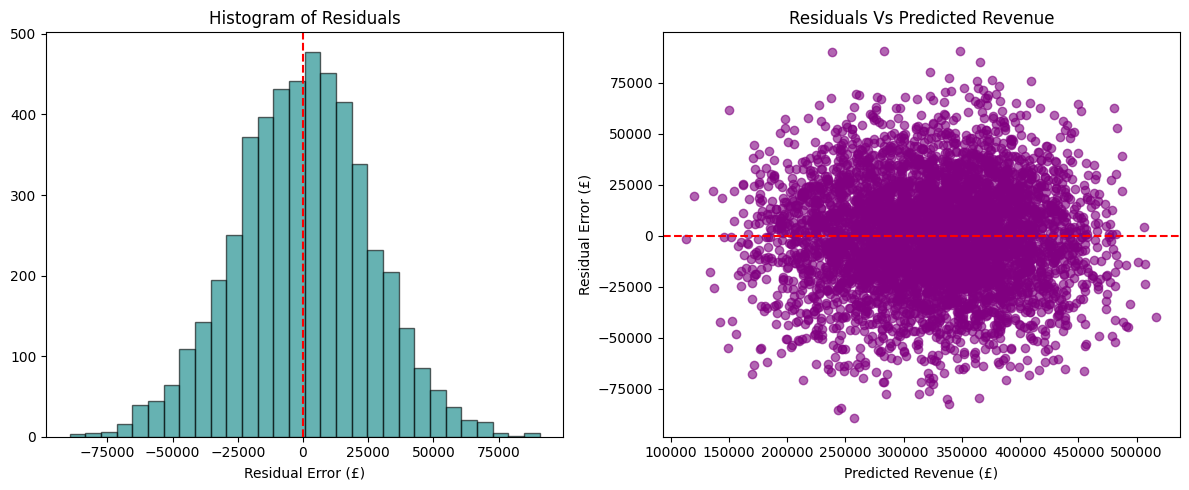

In [96]:
# Creating the Diagnostic Subplots

fig, ax = plt.subplots(1,2, figsize = (12,5))

# Plot A: Histogram of Residuals (Testing for Normality)
ax[0].hist(residuals, bins = 30, color = 'teal', alpha = 0.6, edgecolor = 'black')
ax[0].axvline(0, color = 'red', linestyle = '--')
ax[0].set_title('Histogram of Residuals')
ax[0].set_xlabel('Residual Error (£)')

# Plot B: Residual vs. Predicted Value (Testing for Heteroscedasticity)
ax[1].scatter(cv_predict, residuals, color = 'purple', alpha = 0.6)
ax[1].axhline(0, color = 'red', linestyle = '--')
ax[1].set_title('Residuals Vs Predicted Revenue')
ax[1].set_xlabel('Predicted Revenue (£)')
ax[1].set_ylabel('Residual Error (£)')

plt.tight_layout()
plt.show();

**Key Takeaways**

Plot A: The highest peak is almost at 0 (meaning **most predictions are highly accurate**), and the errors taper off evenly on both the left (under-predictions) and right (over-predictions) sides.

Plot B: A completely random cloud of points evenly scattered above and below the red line across the entire chart is called _Homoscedasticity_ (equal variance). The spread of the purple dots looks like a uniform, blurry rectangle Whether the model predicts a small number or a huge number, its **error range stays roughly the same**.

### 6. Error Analysis (Deep Dive Investigation)

In [102]:
df_errors = pd.DataFrame({
    'Actual_Revenue': y,
    'Predicted_Revenue': cv_predict
})

df_errors['Prediction_Error (£)'] = df_errors['Actual_Revenue'] - df_errors['Predicted_Revenue']

df_errors['Absolute_Error (£)'] = df_errors['Prediction_Error (£)'].abs()

df_errors.head()

,Actual_Revenue,Predicted_Revenue,Prediction_Error (£),Absolute_Error (£)
0,313151.792321,281507.915487,31643.876834,31643.876834
1,354471.126119,395741.041083,-41269.914964,41269.914964
2,436025.243627,397240.130647,38785.112980,38785.112980
3,252781.463673,299610.011114,-46828.547441,46828.547441
4,298776.377299,288585.261138,10191.116161,10191.116161


In [109]:
# Sorting to highlight the 10 largest error

df_top10_failures = df_errors.sort_values(by = 'Absolute_Error (£)', ascending = False).head(10)

df_top10_failures

,Actual_Revenue,Predicted_Revenue,Prediction_Error (£),Absolute_Error (£)
1894,438879.486251,348097.400331,90782.085920,90782.085920
1112,373397.641412,282945.627835,90452.013577,90452.013577
3986,328338.956339,238282.820828,90056.135511,90056.135511
539,167605.469030,257069.022805,-89463.553775,89463.553775
2512,157858.280023,243363.601557,-85505.321534,85505.321534
4782,450940.572281,365504.891707,85435.680573,85435.680573
2834,161768.555036,246305.953923,-84537.398886,84537.398886
3153,256607.478276,338820.064707,-82212.586431,82212.586431
2248,402667.836532,322310.605280,80357.231251,80357.231251
3081,257625.276209,337661.035597,-80035.759388,80035.759388


In [122]:
# Concatenating original X features back to investigate context

df_diagnostic_audit = pd.concat([X.loc[df_top10_failures.index], df_top10_failures], axis = 1)

#  Top 10 Most Catastrophic Prediction Failures
df_diagnostic_audit[['google_spend', 'meta_spend', 'tiktok_spend', 'linkedin_spend', 'email_spend', 'Actual_Revenue', 'Absolute_Error (£)']]

,google_spend,meta_spend,tiktok_spend,linkedin_spend,email_spend,Actual_Revenue,Absolute_Error (£)
1894,28199.162516,15006.269319,6739.295757,10561.835313,3335.336636,438879.486251,90782.085920
1112,11967.063126,27736.937620,607.948296,5068.521387,3248.905490,373397.641412,90452.013577
3986,5672.685142,11593.232838,191.712803,12905.255022,1390.872697,328338.956339,90056.135511
539,7328.811342,14284.199382,9580.814513,8944.914075,3772.527977,167605.469030,89463.553775
2512,22967.633713,1165.773204,3153.773441,1128.864020,4916.235641,157858.280023,85505.321534
4782,28221.928924,21021.402227,17591.264752,4130.172752,3362.531544,450940.572281,85435.680573
2834,20493.994650,5169.444554,6011.822456,6429.683540,557.697641,161768.555036,84537.398886
3153,21952.465351,28319.110935,7012.985659,2496.481150,2201.875150,256607.478276,82212.586431
2248,30349.946901,5305.628307,4188.396336,12298.231969,4321.792729,402667.836532,80357.231251
3081,44266.697417,4684.409730,3393.221625,7016.643975,3967.175998,257625.276209,80035.759388


### 7. Permutation Importance (True Feature Impact)

**Purpose**

It picks the first column (e.g., google_spend) and randomly shuffles (permutes) the values in that column across the test set, destroying any relationship it had with the target variable revenue. All other columns remain perfectly intact.

Then it uses the model to predict on this corrupted dataset and re-calculates the R^2 score. The difference between the baseline score and the corrupted score is the **'importance'**. 

If shuffling google_spend causes R^2 score to plummet, that feature is highly important. If the score stays the same, the feature is useless. 

Repeats: It repeats the process 30 times (n_repeats = 30) per column to get a robust average.

In [141]:
tuned_lasso_pipe.fit(X_train, y_train);

# permutation_importance requires tuned_lasso_pipe to be fitted on training data to provide importance scores on test data

In [132]:
# Run the permutation test 30 times

perm_result = permutation_importance(
    tuned_lasso_pipe, X_test, y_test, n_jobs = -1, random_state = 42,
    n_repeats = 30
    # repeats the process 30 times (n_repeats = 30) per column
)

# Sort and organize into a structured DataFrame

df_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values(by = 'Importance_Mean', ascending = False)

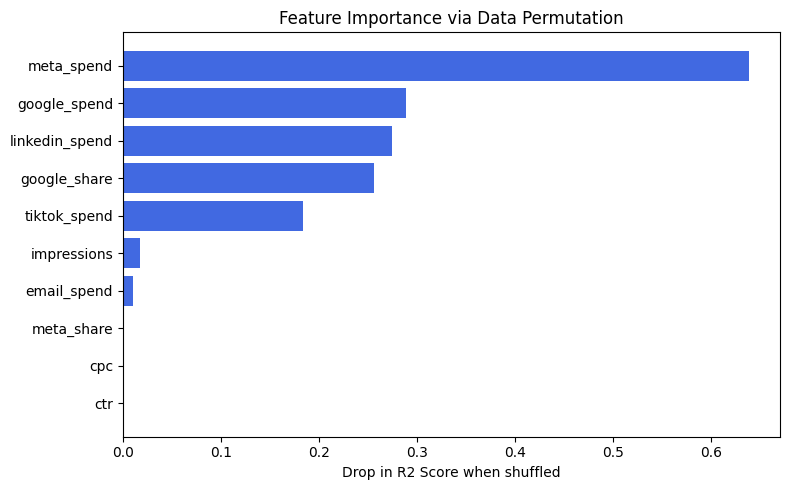

In [143]:
# Plot Permutation Importance

plt.figure(figsize = (8,5))

plt.barh(
    df_importance['Feature'][::-1],
    df_importance['Importance_Mean'][::-1],
    color = 'royalblue'
)

plt.title('Feature Importance via Data Permutation')
plt.xlabel('Drop in R2 Score when shuffled')
plt.tight_layout()
plt.show();

**Key Takeaway**:

Feature importance explains how the model was built, whereas permutation importance explains how much the model depends on each feature for accurate predictions. For this reason, permutation importance is generally considered a more reliable measure of feature relevance, especially when features are correlated.

For this trained model and this synthetic dataset, disturbing Meta Spend caused the largest reduction in predictive performance.